# VCT Match Outcome — Exploratory Data Analysis

This notebook explores the match data in `analytics.fct_matches` and the
leakage-safe features built by `analysis/features.py`, before any model
is trained. The goal here is purely to understand the data: is there
signal in it at all? Are the features actually related to who wins?

If nothing here shows a relationship between the features and the
outcome, building a model afterward would be pointless — this step is
what decides whether modeling is even worth attempting.

In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

sys.path.insert(0, os.path.abspath(".."))
from analysis.features import build_match_features

load_dotenv()
sns.set_style("whitegrid")

## 1. Load raw match data

Same environment variables as the dashboard and load script — no separate config.

In [2]:
host = os.environ.get("POSTGRES_HOST", "localhost")
port = os.environ.get("POSTGRES_PORT", 5432)
dbname = os.environ["POSTGRES_DB"]
user = os.environ["POSTGRES_USER"]
password = os.environ["POSTGRES_PASSWORD"]

engine = create_engine(f"postgresql+pg8000://{user}:{password}@{host}:{port}/{dbname}")

with engine.connect() as conn:
    matches = pd.read_sql(text("SELECT * FROM analytics.fct_matches"), conn)

print(f"Loaded {len(matches)} matches")
matches.head()

Loaded 1621 matches


,match_id,match_name,match_status,match_type,number_of_games,is_forfeit,begin_at,end_at,duration_minutes,tournament_id,...,league_name,videogame_version,team_a_id,team_a_name,team_a_score,team_b_id,team_b_name,team_b_score,winner_id,winner_name
0,911572,Round 1: KC vs VIT,finished,best_of,3,False,2024-02-26 13:06:12+00:00,2024-02-26 15:20:38+00:00,134.433333,12820,...,VCT,8.02,128796,Team Vitality,0,130922,Karmine Corp,2,130922,Karmine Corp
1,911573,Round 2: KOI vs VIT,finished,best_of,3,False,2024-02-26 15:42:09+00:00,2024-02-26 17:23:54+00:00,101.750000,12820,...,VCT,8.02,128796,Team Vitality,2,130412,Movistar KOI,0,128796,Team Vitality
2,911574,Round 3: KC vs KOI,finished,best_of,3,False,2024-02-26 17:53:13+00:00,2024-02-26 19:26:34+00:00,93.350000,12820,...,VCT,8.02,130412,Movistar KOI,0,130922,Karmine Corp,2,130922,Karmine Corp
3,911576,Semifinal 1: TH vs NAVI,finished,best_of,3,False,2024-02-29 16:03:47+00:00,2024-02-29 17:56:07+00:00,112.333333,12821,...,VCT,8.02,128622,Team Heretics,2,129355,Natus Vincere,0,128622,Team Heretics
4,911577,Semifinal 2: FNC vs KC,finished,best_of,3,False,2024-02-29 18:23:52+00:00,2024-02-29 20:27:43+00:00,123.850000,12821,...,VCT,8.02,128537,Fnatic,0,130922,Karmine Corp,2,130922,Karmine Corp


## 2. Build leakage-safe features

Using the same function that unit tests already validate.

In [3]:
features = build_match_features(matches)
print(f"{len(features)} finished matches with features built")
features[[
    "match_id", "team_a_name", "team_b_name",
    "team_a_rolling_winrate", "team_b_rolling_winrate",
    "h2h_team_a_winrate", "team_a_won"
]].head(10)

1621 finished matches with features built


,match_id,team_a_name,team_b_name,team_a_rolling_winrate,team_b_rolling_winrate,h2h_team_a_winrate,team_a_won
0,912371,NRG,FURIA Esports,NaN,NaN,NaN,1
1,912372,Cloud9,MIBR,NaN,NaN,NaN,1
2,911955,T1,Bleed eSports,NaN,NaN,NaN,1
3,911965,Gen.G Esports,Rex Regum Qeon,NaN,NaN,NaN,1
4,912377,Sentinels,LOUD,NaN,NaN,NaN,0
5,912378,100 Thieves,Leviatán Esports,NaN,NaN,NaN,0
6,911957,ZETA DIVISION,Global Esports,NaN,NaN,NaN,1
7,911961,Team Secret,Talon Esports,NaN,NaN,NaN,0
8,911959,Kiwoom DRX,DetonatioN FocusMe,NaN,NaN,NaN,1
9,912383,G2 Esports,KRÜ Esports,NaN,NaN,NaN,1


## 3. Class balance

Before trusting any model's accuracy number, check whether the target is
roughly balanced. If ~95% of matches were won by "team_a" for some
structural reason, a model could hit 95% accuracy by always predicting
"team_a wins" — a useless model that *looks* great on paper.

In [4]:
features["team_a_won"].value_counts(normalize=True)

team_a_won
1    0.567551
0    0.432449
Name: proportion, dtype: float64

## 4. Does recent form actually predict winning?

This is the key question this whole notebook exists to answer. We compare
each match's *form gap* (team A's rolling win rate minus team B's) against
the actual outcome. If better recent form doesn't correlate with winning
more, the feature isn't worth including in a model.

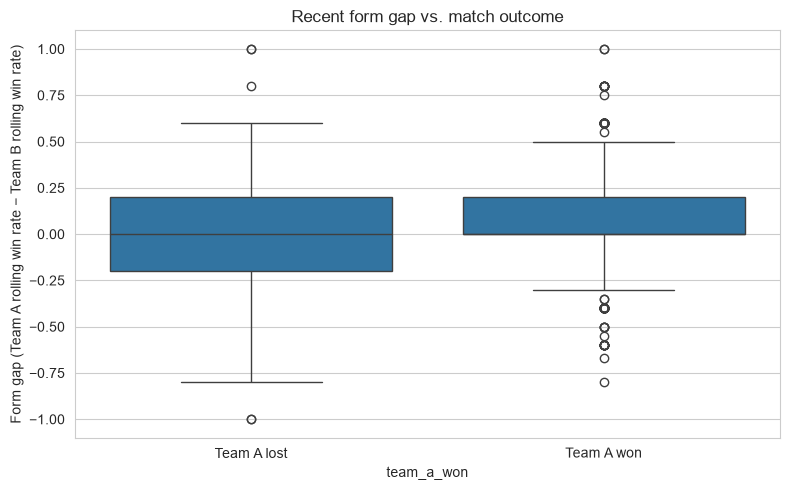

In [5]:
plot_df = features.dropna(subset=["team_a_rolling_winrate", "team_b_rolling_winrate"]).copy()
plot_df["form_gap"] = plot_df["team_a_rolling_winrate"] - plot_df["team_b_rolling_winrate"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_df, x="team_a_won", y="form_gap", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Team A lost", "Team A won"])
ax.set_ylabel("Form gap (Team A rolling win rate − Team B rolling win rate)")
ax.set_title("Recent form gap vs. match outcome")
plt.tight_layout()
plt.savefig("form_gap_vs_outcome.png", dpi=120)
plt.show()

If the pipeline is working and the data has real signal, the "Team A
won" box should sit noticeably higher than the "Team A lost" box — i.e.,
teams in better recent form going into a match tend to actually win it.

## 5. Head-to-head history: does it matter?

1046 matches had at least one prior meeting between the same two teams


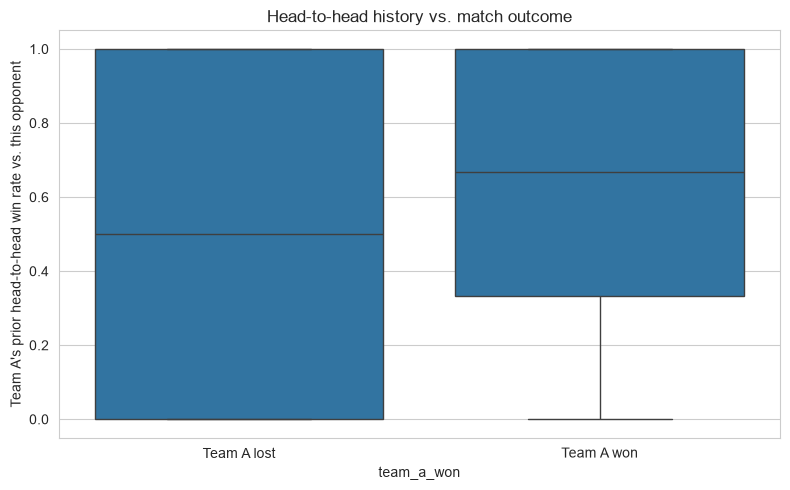

In [6]:
h2h_df = features.dropna(subset=["h2h_team_a_winrate"]).copy()
print(f"{len(h2h_df)} matches had at least one prior meeting between the same two teams")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=h2h_df, x="team_a_won", y="h2h_team_a_winrate", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Team A lost", "Team A won"])
ax.set_ylabel("Team A's prior head-to-head win rate vs. this opponent")
ax.set_title("Head-to-head history vs. match outcome")
plt.tight_layout()
plt.savefig("h2h_vs_outcome.png", dpi=120)
plt.show()

## 6. Correlation between numeric features and the outcome

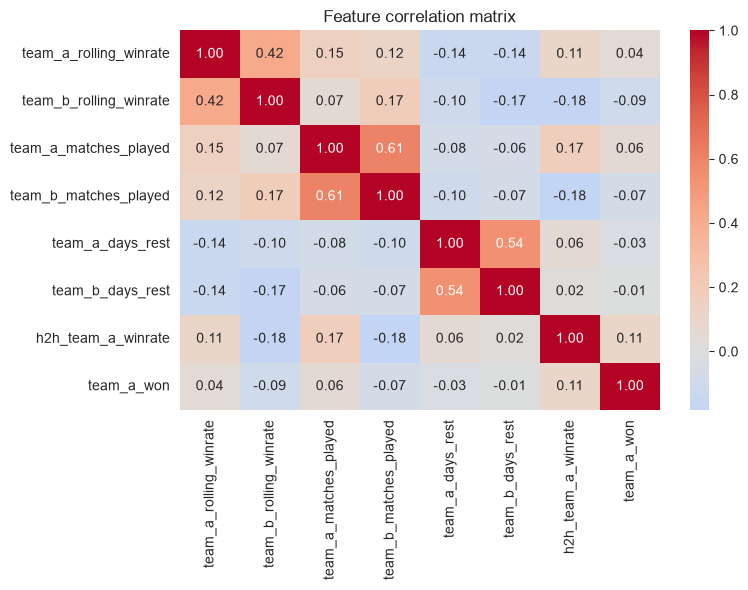

In [7]:
numeric_cols = [
    "team_a_rolling_winrate", "team_b_rolling_winrate",
    "team_a_matches_played", "team_b_matches_played",
    "team_a_days_rest", "team_b_days_rest",
    "h2h_team_a_winrate", "team_a_won",
]
corr = features[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=120)
plt.show()

## 7. Missing data check

Every team's first-ever match has no prior stats (by design — see
`features.py`), so some `NaN`s here are expected and correct, not a bug.

In [8]:
features[numeric_cols].isna().mean().sort_values(ascending=False)

h2h_team_a_winrate        0.354719
team_b_rolling_winrate    0.035163
team_b_days_rest          0.035163
team_a_rolling_winrate    0.024676
team_a_days_rest          0.024676
team_a_matches_played     0.000000
team_b_matches_played     0.000000
team_a_won                0.000000
dtype: float64

## 8. Export for modeling

Saves the feature-engineered dataset so `train_model.py` doesn't need a
live database connection to run — useful for anyone reviewing this repo
without setting up the full pipeline.

In [9]:
os.makedirs("data", exist_ok=True)
features.to_csv("data/match_features.csv", index=False)
print(f"Saved {len(features)} rows to data/match_features.csv")

Saved 1621 rows to data/match_features.csv
